In [1]:
import time
import torch
import torch.nn.functional as F
import matplotlib.pyplot as plt
import numpy as np
from mpl_toolkits.mplot3d import Axes3D
from skimage import measure

import sys, os
sys.path.append(os.path.abspath("../src"))

from core import *
import viz as viz

In [2]:
def make_sphere_target(grid_size, radius, device='cpu'):
    D, H, W = grid_size
    cz, cy, cx = D / 2.0, H / 2.0, W / 2.0
    zz = torch.arange(0, D, device=device).view(D, 1, 1).expand(D, H, W).float()
    yy = torch.arange(0, H, device=device).view(1, H, 1).expand(D, H, W).float()
    xx = torch.arange(0, W, device=device).view(1, 1, W).expand(D, H, W).float()
    dist = torch.sqrt((zz - cz) ** 2 + (yy - cy) ** 2 + (xx - cx) ** 2)
    occ = (dist <= radius).float()
    return occ.unsqueeze(0).unsqueeze(0)

In [3]:
def train_multi_step(model: Grid3D, cell_cfg: CellConfig, grid_cfg: GridConfig,
                     device='cpu', iters=2000, n_steps=8, log_interval=200):
    model.to(device)
    optim = torch.optim.AdamW(model.parameters(), lr=1e-3, weight_decay=1e-5)

    target = make_sphere_target(grid_cfg.size, radius=min(grid_cfg.size)/4.0, device=device)

    losses = []
    for it in range(1, iters+1):
        state = model.seed_center(batch_size=1, device=device)
        state += 0.02 * torch.randn_like(state)

        optim.zero_grad()
        loss = 0.0
        for step in range(n_steps):
            state = model(state, steps=1)
            alpha = state[:, -1:, ...]
            loss += F.mse_loss(alpha, target)

        loss.backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
        optim.step()

        losses.append(loss.item())

        if it % log_interval == 0 or it==1:
            print(f"Iter {it:05d}, Loss={loss.item():.6f}, Mean Alpha={alpha.mean().item():.4f}")
            viz.show_comparison(state, target, idx=16)
        if loss.item() < 0.35:
            print("Best result")
            print(f"Iter {it:05d}, Loss={loss.item():.6f}, Mean Alpha={alpha.mean().item():.4f}")
            viz.show_comparison(state, target, idx=16)
            break

    return losses


device -> cuda
stability run:
step 00 mean=+0.000003 std=0.001842
step 01 mean=+0.000003 std=0.001845
step 02 mean=+0.000003 std=0.001856
step 03 mean=+0.000003 std=0.001901
step 04 mean=+0.000002 std=0.002068
step 05 mean=+0.000001 std=0.002633
step 06 mean=-0.000001 std=0.004189
step 07 mean=-0.000005 std=0.007747

starting single-step supervised training (tiny)
Iter 00001, Loss=0.936962, Mean Alpha=0.0057


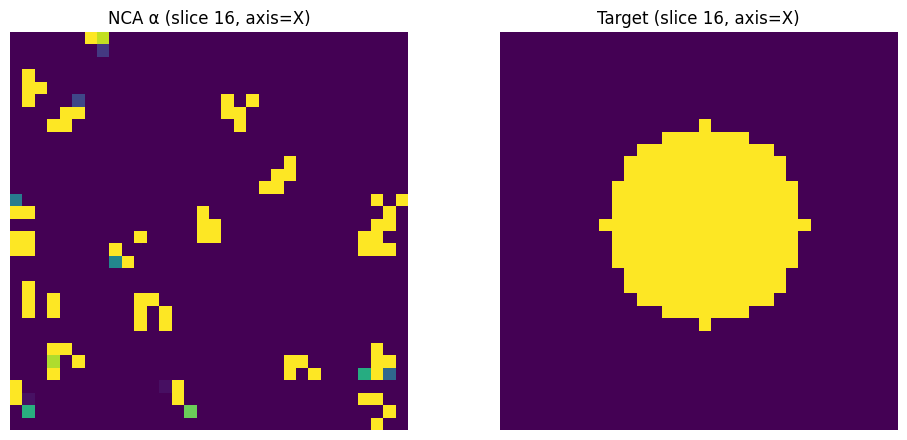

Iter 00200, Loss=0.486807, Mean Alpha=0.0937


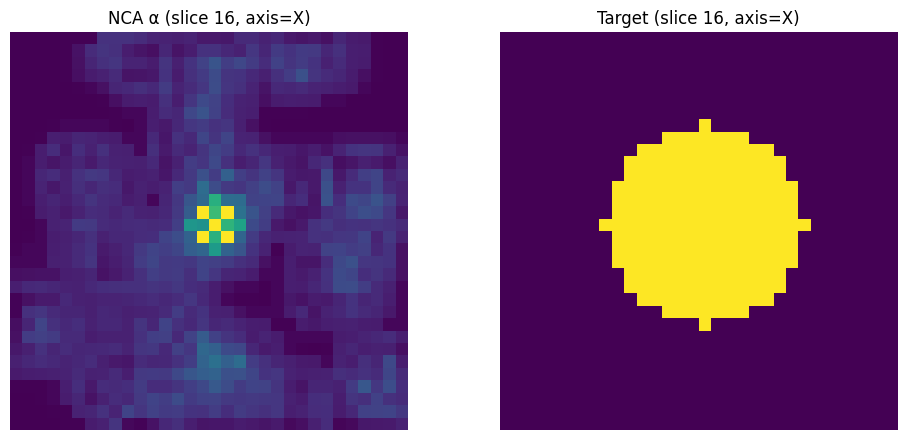

Iter 00400, Loss=0.461413, Mean Alpha=0.1283


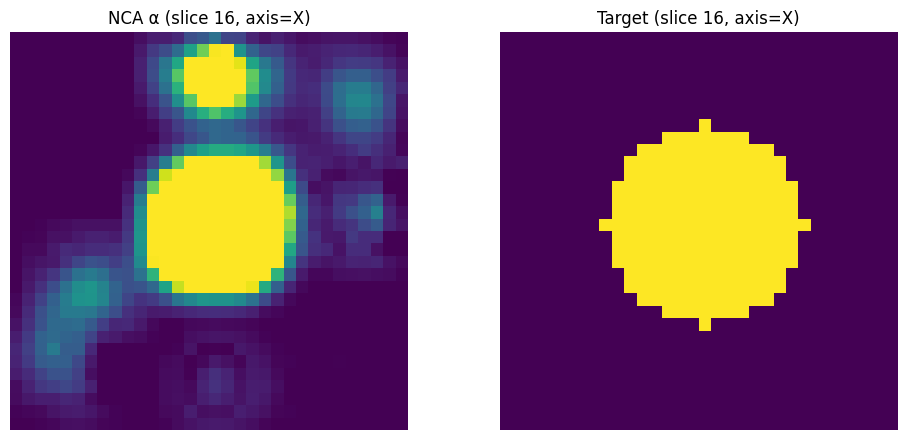

Iter 00600, Loss=0.515962, Mean Alpha=0.1672


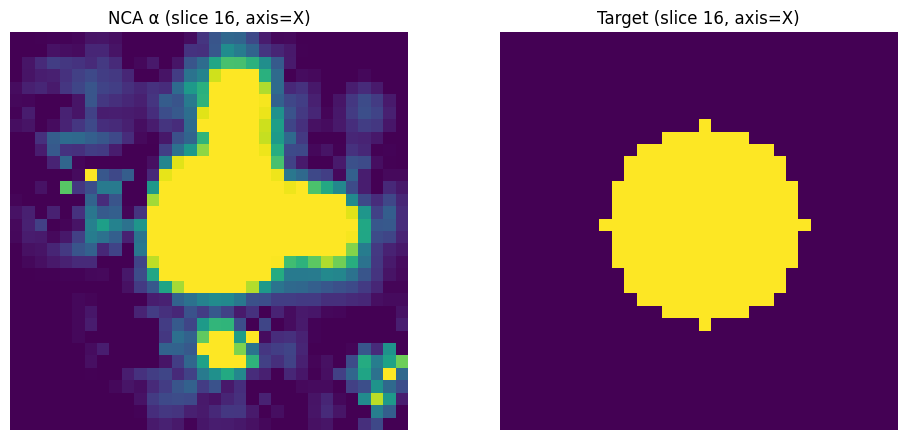

Iter 00800, Loss=0.385455, Mean Alpha=0.0531


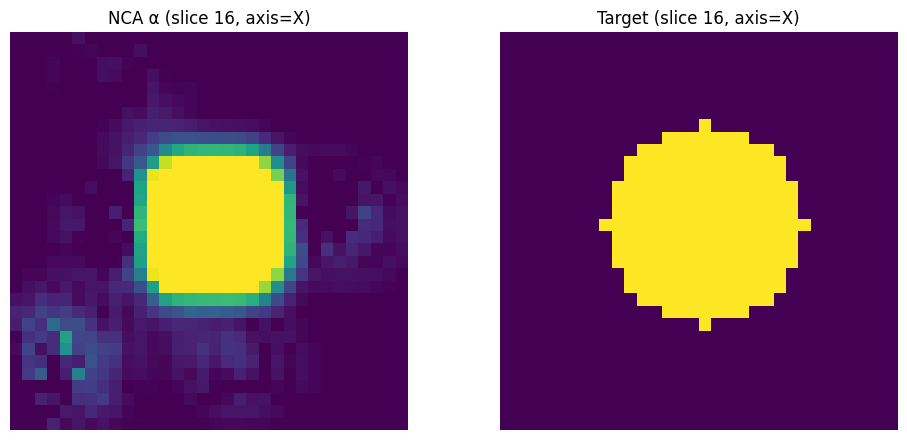

Iter 01000, Loss=0.494499, Mean Alpha=0.0580


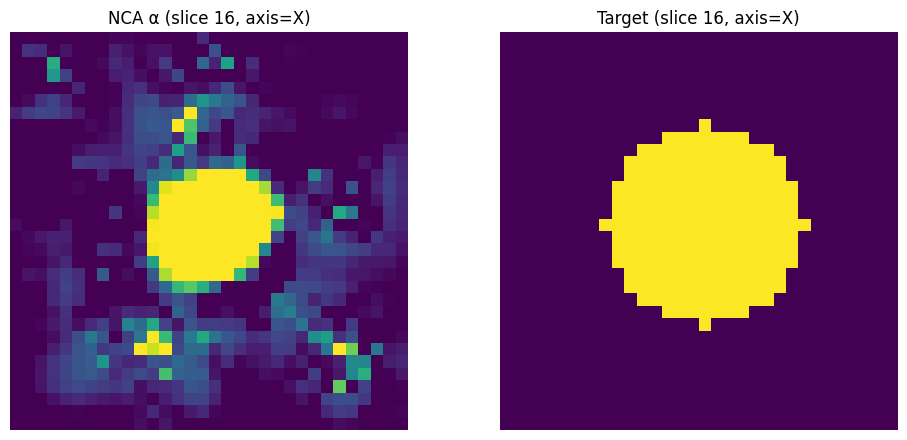

Iter 01200, Loss=0.393696, Mean Alpha=0.0992


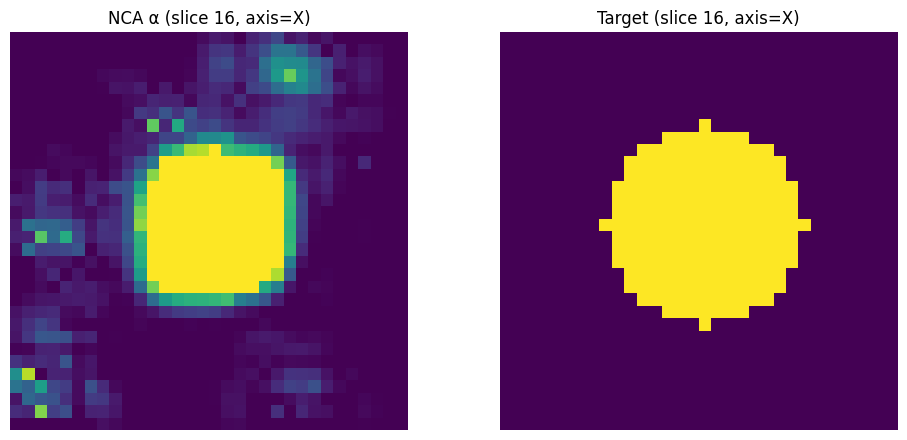

Iter 01400, Loss=0.362689, Mean Alpha=0.0573


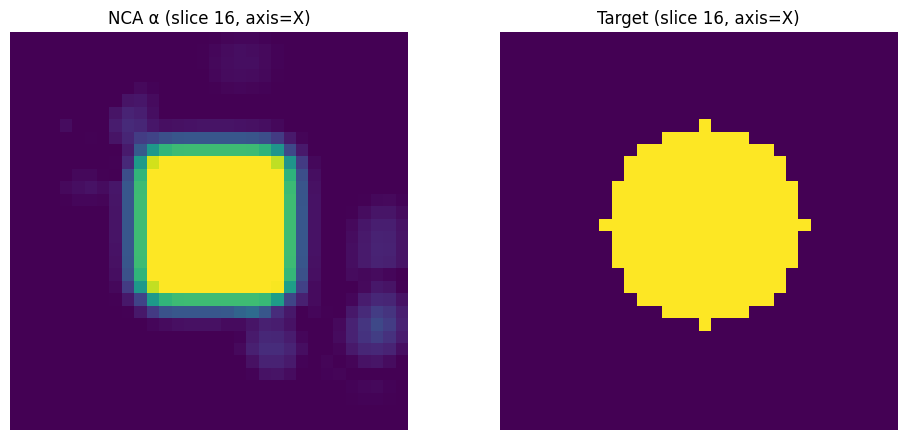

Iter 01600, Loss=0.357922, Mean Alpha=0.0679


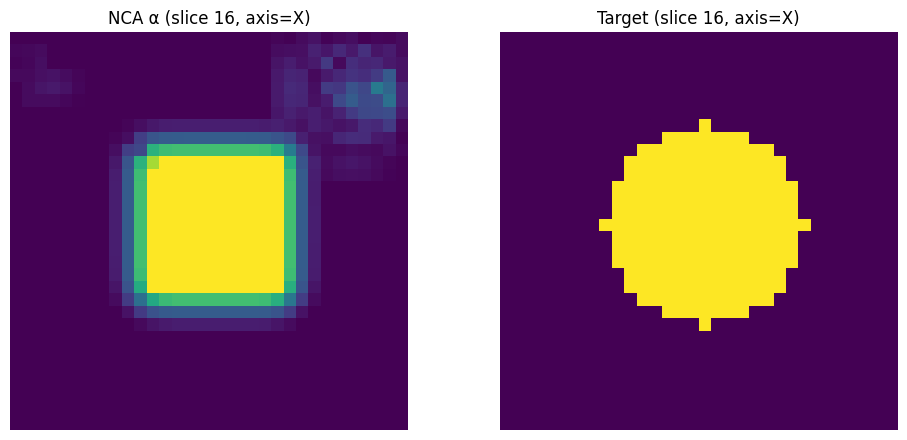

Iter 01800, Loss=0.355928, Mean Alpha=0.0609


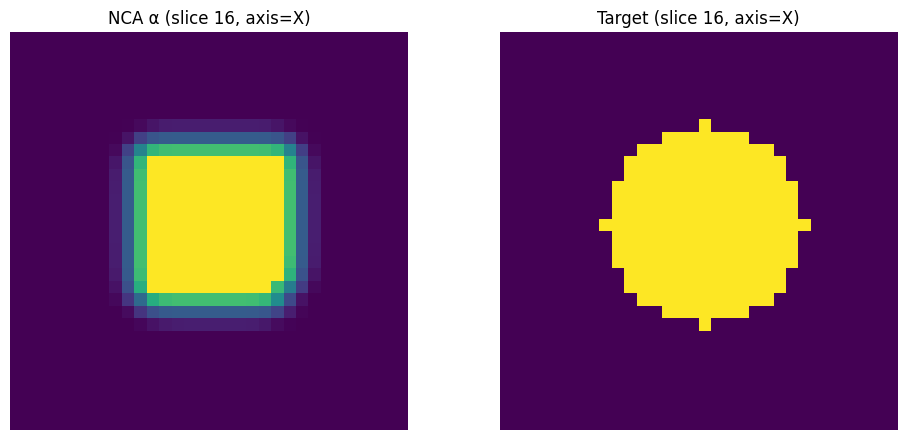

Best result
Iter 01978, Loss=0.349979, Mean Alpha=0.0655


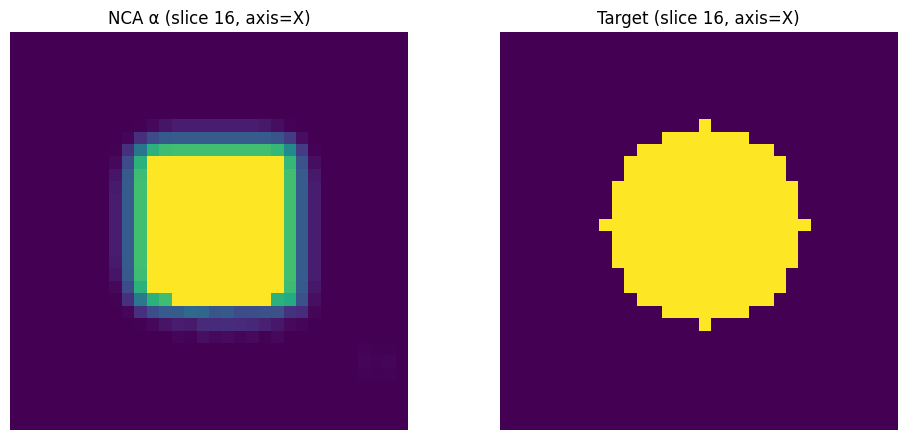

training took 95.30032086372375 s
final alive voxels: 2891


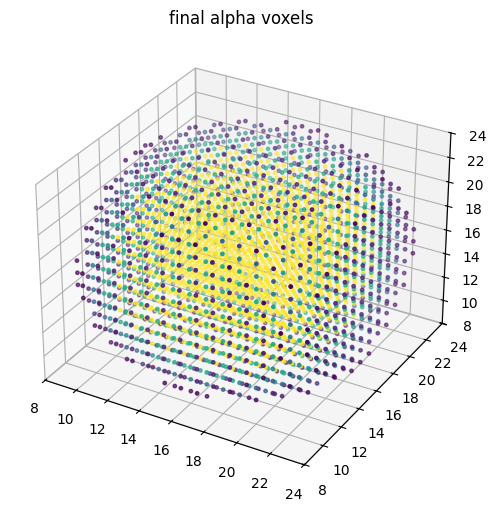

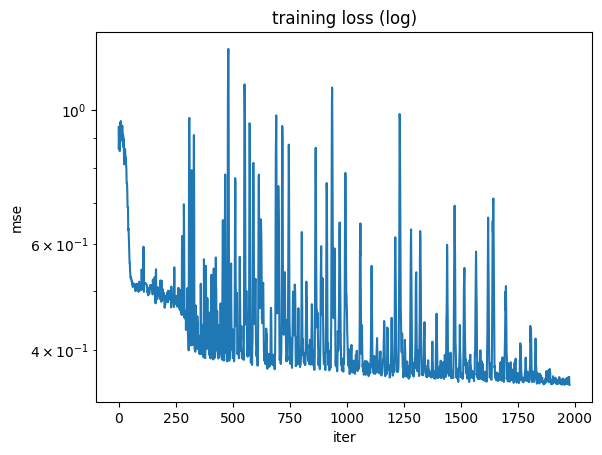

In [4]:
if __name__ == "__main__":
    device = "cuda" if torch.cuda.is_available() else "cpu"
    print("device ->", device)

    cell_cfg = CellConfig(hidden_channels=8, visible_channels=1, alive_threshold=0.05)
    perc_cfg = PerceptionConfig(kernel_radius=1, channel_groups=3)
    upd_cfg = UpdateConfig(hidden_dim=64, stochastic_update=False, fire_rate=0.5)
    grid_cfg = GridConfig(size=(32, 32, 32))

    model = Grid3D(cell_cfg, perc_cfg, upd_cfg, grid_cfg).to(device)

    print("stability run:")
    state = model.seed_center(batch_size=1, device=device)
    state += 1e-3 * torch.randn_like(state)
    with torch.no_grad():
        for i in range(8):
            state = model(state, steps=1)
            print(f"step {i:02d} mean={state.mean().item():+.6f} std={state.std().item():.6f}")

    print("\nstarting single-step supervised training (tiny)")
    start = time.time()
    losses = train_multi_step(model, cell_cfg, grid_cfg, device=device)
    print("training took", time.time() - start, "s")

    with torch.no_grad():
        state = model.seed_center(batch_size=1, device=device)
        state += 1e-3 * torch.randn_like(state)
        state = model(state, steps=8)
        alpha = state[:, -1:, ...].cpu().numpy().squeeze()

    thresh = 0.2
    xs, ys, zs = np.nonzero(alpha > thresh)
    print("final alive voxels:", len(xs))

    fig = plt.figure(figsize=(6, 6))
    ax = fig.add_subplot(111, projection="3d")
    ax.scatter(xs, ys, zs, s=6, c=alpha[alpha > thresh])
    ax.set_title("final alpha voxels")
    plt.show()

    plt.figure()
    plt.plot(losses)
    plt.yscale("log")
    plt.title("training loss (log)")
    plt.xlabel("iter")
    plt.ylabel("mse")
    plt.show()